In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import layers
import torch.nn as nn

**Output Size Formula:**

`
Output Size = (Input Size - Filter Size + 2×Padding) / Stride + 1
`

In [2]:
def calculate_output_size(input_size, filter_size, padding, stride):
    return (input_size - filter_size + 2 * padding) // stride + 1

1. No padding, stride 1

In [3]:
input_size = 32
kernal_size = 3
padding = 0
stride = 1

output_size = calculate_output_size(input_size, kernal_size, padding, stride)

print(f"Input: {input_size}x{input_size}, Filter: {kernal_size}x{kernal_size}")
print(f"Padding: {padding}, Stride: {stride}")
print(f"Output: {output_size}x{output_size}")

Input: 32x32, Filter: 3x3
Padding: 0, Stride: 1
Output: 30x30


2. padding 1, stride 1

In [4]:
padding = 1
output_size = calculate_output_size(input_size, kernal_size, padding, stride)

print(f"\nWith padding={padding}: Output: {output_size}x{output_size}")


With padding=1: Output: 32x32


3. Stride 2 (downsampling), padding 1

In [5]:
stride = 2

output_size = calculate_output_size(input_size, kernal_size, padding, stride)

print(f"\nWith Stride={stride}: Output: {output_size}x{output_size}")


With Stride=2: Output: 16x16


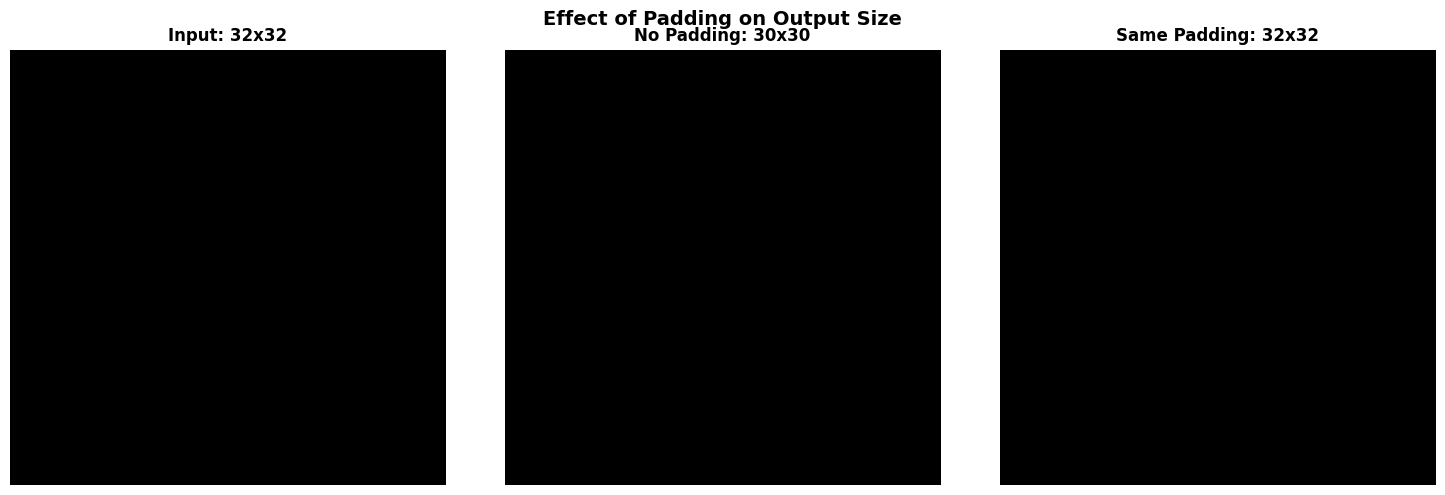

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Original image
original = np.ones((32, 32))
axes[0].imshow(original, cmap='gray')
axes[0].set_title(f'Input: {original.shape[0]}x{original.shape[1]}', fontweight='bold')
axes[0].axis('off')

# After convolution (no padding, stride 1)
no_pad = np.ones((30, 30))  # 32-3+1 = 30
axes[1].imshow(no_pad, cmap='gray')
axes[1].set_title(f'No Padding: {no_pad.shape[0]}x{no_pad.shape[1]}', fontweight='bold')
axes[1].axis('off')

# After convolution (same stride, padding 1)
same_pad = np.ones((32, 32))  # Same size
axes[2].imshow(same_pad, cmap='gray')
axes[2].set_title(f'Same Padding: {same_pad.shape[0]}x{same_pad.shape[1]}', fontweight='bold')
axes[2].axis('off')

plt.suptitle('Effect of Padding on Output Size', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Key Rules:**

- For 3x3 kernel: padding=1 gives same size output (with stride=1)
- For 5x5 kernel: padding=2 gives same size output (with stride=1)

- General rule: padding = (kernel_size - 1) / 2 for same size

**Implementation in keras**

In [ ]:
# Valid padding (no padding)
conv_valid = layers.Conv2D(32, (3, 3), padding='valid', strides=1)

# Same padding (preserve size)
conv_same = layers.Conv2D(32, (3, 3), padding='same', strides=1)


# Stride 2 for downsampling
conv_stride2 = layers.Conv2D(64, (3, 3), padding='same', strides=2)

# Custom padding
conv_custom = layers.Conv2D(32, (3, 3), padding=1, strides=1)

**Implementation in Pytorch**

In [ ]:
# Valid padding (no padding)
conv_valid = nn.Conv2d(1, 32, kernel_size=3, padding=0, stride=1)

# Same padding (for 3x3 kernel, padding=1 gives same size)
conv_same = nn.Conv2d(1, 32, kernel_size=3, padding=1, stride=1)

# Stride 2 for downsampling
conv_stride2 = nn.Conv2d(32, 64, kernel_size=3, padding=1, stride=2)